In [2]:
import numpy as np  
import pandas as pd  

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"] = (14, 5)
os.makedirs("docs", exist_ok=True)  

COMP = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting"

def load_merged(kind: str = "train") -> pd.DataFrame:
    if kind not in ("train", "test"):
        raise ValueError("kind must be 'train' or 'test'")
    base = pd.read_csv(f"{COMP}/{kind}.csv.zip")
    base["Date"] = pd.to_datetime(base["Date"])
    stores = pd.read_csv(f"{COMP}/stores.csv")
    feats = pd.read_csv(f"{COMP}/features.csv.zip")
    feats["Date"] = pd.to_datetime(feats["Date"])
    feats = feats.drop(columns=["IsHoliday"]) 
    return (
        base.merge(stores, on="Store", how="left")
            .merge(feats, on=["Store", "Date"], how="left")
            .sort_values(["Store", "Dept", "Date"])
            .reset_index(drop=True)
    )

df_train = load_merged("train")
df_test = load_merged("test")
print("Train:", df_train.shape, "| Test:", df_test.shape)
df_train.head()
stores.head()

ModuleNotFoundError: No module named 'seaborn'

In [3]:
print("Train:", df_train.Date.min().date(), "->", df_train.Date.max().date())
print("Test :", df_test.Date.min().date(), "->", df_test.Date.max().date())
print("Stores:", df_train.Store.nunique(), "| Departments:", df_train.Dept.nunique(),
      "| Series (Store x Dept):", df_train.groupby(["Store","Dept"]).ngroups)
print("\nMissing % per column:")
print((df_train.isna().mean()*100).round(6).sort_values(ascending=False).head(15))

Train: 2010-02-05 -> 2012-10-26
Test : 2012-11-02 -> 2013-07-26
Stores: 45 | Departments: 81 | Series (Store x Dept): 3331

Missing % per column:
MarkDown2       73.611025
MarkDown4       67.984676
MarkDown3       67.480845
MarkDown1       64.257181
MarkDown5       64.079038
Store            0.000000
Date             0.000000
Dept             0.000000
Temperature      0.000000
Size             0.000000
Type             0.000000
IsHoliday        0.000000
Weekly_Sales     0.000000
Fuel_Price       0.000000
CPI              0.000000
dtype: float64


In [ ]:
from scipy.signal import find_peaks

weekly = df_train.groupby("Date")["Weekly_Sales"].sum().reset_index()
weekly["IsHoliday"] = weekly["Date"].map(df_train.groupby("Date")["IsHoliday"].first())

HOLIDAY_BY_MONTH = {2: "Super Bowl", 9: "Labor Day", 11: "Thanksgiving", 12: "Christmas"}
HOLIDAY_COLOR   = {"Super Bowl": "tab:blue", "Labor Day": "tab:green",
                   "Thanksgiving": "tab:orange", "Christmas": "tab:red"}
hol = (df_train.loc[df_train["IsHoliday"], "Date"].drop_duplicates().sort_values())
hol = pd.DataFrame({"Date": hol})
hol["name"] = hol["Date"].dt.month.map(HOLIDAY_BY_MONTH).fillna("Holiday")

plt.figure()
sns.lineplot(data=weekly, x="Date", y="Weekly_Sales")

for _, r in hol.iterrows():
    plt.axvline(r["Date"], color=HOLIDAY_COLOR.get(r["name"], "grey"),
                linestyle="--", alpha=0.5, linewidth=1, zorder=1)
from matplotlib.lines import Line2D
legend = [Line2D([0], [0], color=c, linestyle="--", label=n)
          for n, c in HOLIDAY_COLOR.items() if n in set(hol["name"])]

peaks, _ = find_peaks(weekly["Weekly_Sales"], distance=8)
top = weekly["Weekly_Sales"].iloc[peaks].nlargest(4).index
plt.scatter(weekly.Date.iloc[top], weekly.Weekly_Sales.iloc[top],
            color="red", zorder=5, s=80, label="top peaks")
for i in top:
    plt.annotate(weekly.Date.iloc[i].strftime("%Y-%m-%d"),
                 (weekly.Date.iloc[i], weekly.Weekly_Sales.iloc[i]), fontsize=8)

plt.legend(handles=legend + [Line2D([0], [0], marker="o", color="w",
           markerfacecolor="red", markersize=8, label="top peaks")], loc="upper left")
plt.title("Total Weekly Sales Over Time (dashed = holiday weeks, red = top peaks)")
plt.tight_layout(); plt.savefig("docs/eda_total_sales.png", dpi=90); plt.show()

print("Top 6 sales weeks (the ones a model must get right):")
print(weekly.nlargest(6, "Weekly_Sales")
            .assign(Weekly_Sales=lambda d: (d.Weekly_Sales / 1e6).round(2))
            .rename(columns={"Weekly_Sales": "Total_M$"})
            .to_string(index=False))

xmas = weekly[weekly.IsHoliday & (weekly.Date.dt.month == 12)]
print(f"\nWeeks flagged IsHoliday=True in December (these get weight 5):")
print(xmas.assign(Weekly_Sales=lambda d: (d.Weekly_Sales / 1e6).round(2))
          .rename(columns={"Weekly_Sales": "Total_M$"}).to_string(index=False))
print(f"\nMean weekly total across the whole training period: "
      f"{weekly.Weekly_Sales.mean()/1e6:.2f}M")

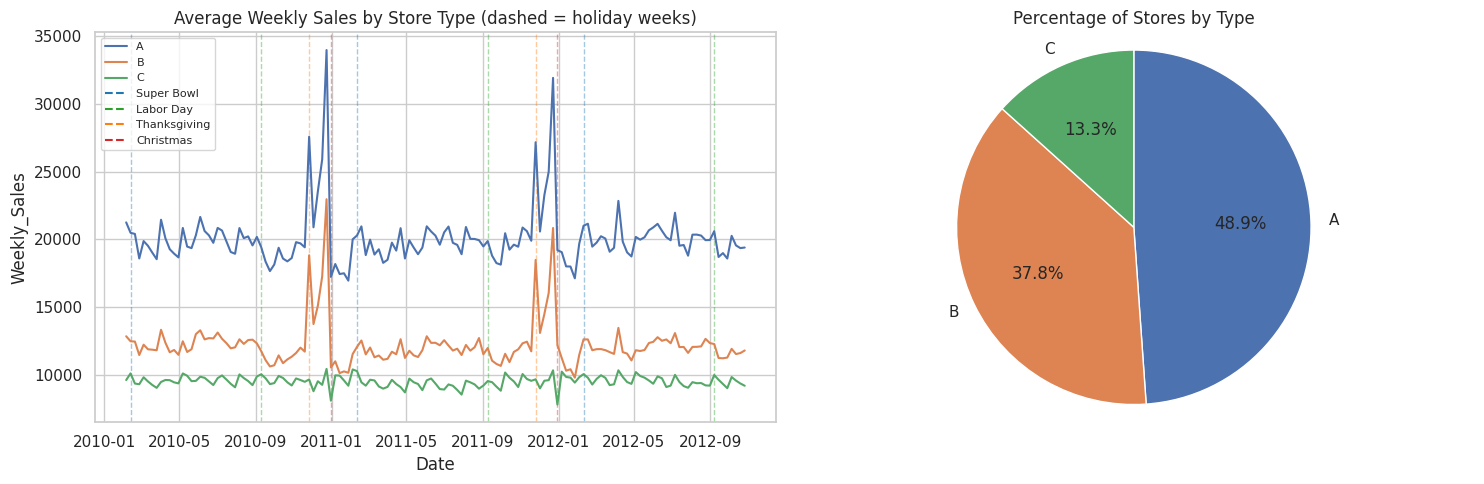

Avg sales by type: {'A': 20100, 'B': 12237, 'C': 9520}


In [5]:
from matplotlib.lines import Line2D

HOLIDAY_BY_MONTH = {2: "Super Bowl", 9: "Labor Day", 11: "Thanksgiving", 12: "Christmas"}
HOLIDAY_COLOR    = {"Super Bowl": "tab:blue", "Labor Day": "tab:green",
                    "Thanksgiving": "tab:orange", "Christmas": "tab:red"}
hol = df_train.loc[df_train["IsHoliday"], "Date"].drop_duplicates().sort_values().to_frame()
hol["name"] = hol["Date"].dt.month.map(HOLIDAY_BY_MONTH).fillna("Holiday")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
by_type_time = df_train.groupby(["Type","Date"])["Weekly_Sales"].mean().reset_index()
sns.lineplot(data=by_type_time, x="Date", y="Weekly_Sales", hue="Type", ax=ax[0])

for _, r in hol.iterrows():
    ax[0].axvline(r["Date"], color=HOLIDAY_COLOR.get(r["name"], "grey"),
                  linestyle="--", alpha=0.4, linewidth=1, zorder=1)
hol_handles = [Line2D([0],[0], color=c, linestyle="--", label=n)
               for n, c in HOLIDAY_COLOR.items() if n in set(hol["name"])]
type_handles, _ = ax[0].get_legend_handles_labels()
ax[0].legend(handles=type_handles + hol_handles, loc="upper left", fontsize=8)
ax[0].set_title("Average Weekly Sales by Store Type (dashed = holiday weeks)")

type_pct = df_train.drop_duplicates("Store").Type.value_counts(normalize=True).sort_index()*100
ax[1].pie(type_pct.values, labels=type_pct.index, autopct="%1.1f%%", startangle=90,
          counterclock=False, wedgeprops={"edgecolor": "white"})
ax[1].set_title("Percentage of Stores by Type"); ax[1].axis("equal")
plt.tight_layout(); plt.savefig("docs/eda_store_type.png", dpi=90); plt.show()
print("Avg sales by type:", {k:round(v) for k,v in df_train.groupby("Type").Weekly_Sales.mean().items()})

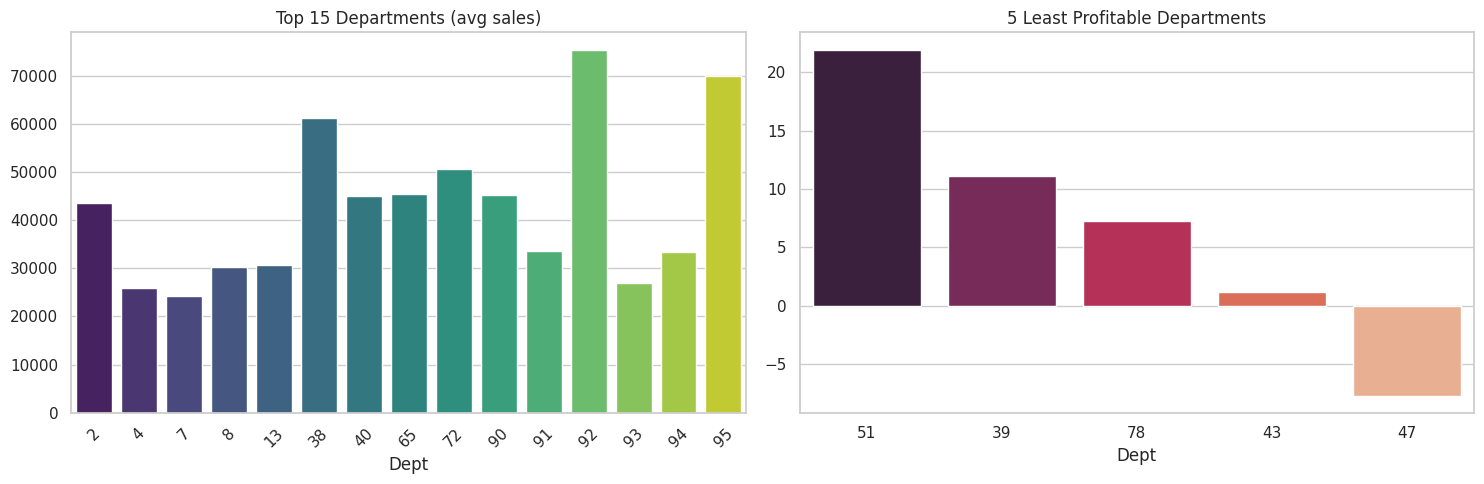

Most profitable: {92: 75205.0, 95: 69824.0, 38: 61091.0}
Departments with negative avg: {47: -8.0}


In [6]:
dept_avg = df_train.groupby("Dept")["Weekly_Sales"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=dept_avg.head(15).index, y=dept_avg.head(15).values, ax=ax[0], palette="viridis")
ax[0].set_title("Top 15 Departments (avg sales)"); ax[0].tick_params(axis="x", rotation=45)
sns.barplot(x=dept_avg.tail(5).index.astype(str), y=dept_avg.tail(5).values, ax=ax[1], palette="rocket")
ax[1].set_title("5 Least Profitable Departments");
plt.tight_layout(); plt.savefig("docs/eda_departments.png", dpi=90); plt.show()
print("Most profitable:", dept_avg.head(3).round().to_dict())
print("Departments with negative avg:", dept_avg[dept_avg<0].round().to_dict())

In [ ]:
weeks_per_month = df_train.groupby(df_train.Date.dt.month)["Date"].nunique()
years_per_month = df_train.groupby(df_train.Date.dt.month)["Date"].apply(lambda s: s.dt.year.nunique())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

monthly_sum = df_train.groupby(df_train.Date.dt.month)["Weekly_Sales"].sum()
sns.barplot(x=monthly_sum.index.astype(str), y=monthly_sum.values / 1e6, ax=ax[0], palette="Greens_d")
ax[0].set_title("WRONG: Total Sales by Month (confounded by exposure)")
ax[0].set_xlabel("Month"); ax[0].set_ylabel("Total sales (M$)")

weekly_tot = df_train.groupby("Date")["Weekly_Sales"].sum()
monthly_mean = weekly_tot.groupby(weekly_tot.index.month).mean()
sns.barplot(x=monthly_mean.index.astype(str), y=monthly_mean.values / 1e6, ax=ax[1], palette="Reds_d")
ax[1].axhline(weekly_tot.mean() / 1e6, ls="--", c="grey", label="overall weekly mean")
ax[1].set_title("CORRECT: Mean Sales per Observed Week")
ax[1].set_xlabel("Month"); ax[1].set_ylabel("Mean sales per week (M$)"); ax[1].legend()

plt.tight_layout(); plt.savefig("docs/eda_seasonality.png", dpi=90); plt.show()

summary = pd.DataFrame({
    "years_observed": years_per_month,
    "weeks_observed": weeks_per_month,
    "total_M$": (monthly_sum / 1e6).round(1),
    "mean_per_week_M$": (monthly_mean / 1e6).round(2),
})
summary.index.name = "month"
print("Exposure per month - why the two panels disagree:")
print(summary.to_string())
print(f"\nBy total:        top months = {list(monthly_sum.nlargest(3).index)}")
print(f"By mean/week:    top months = {list(monthly_mean.nlargest(3).index)}")

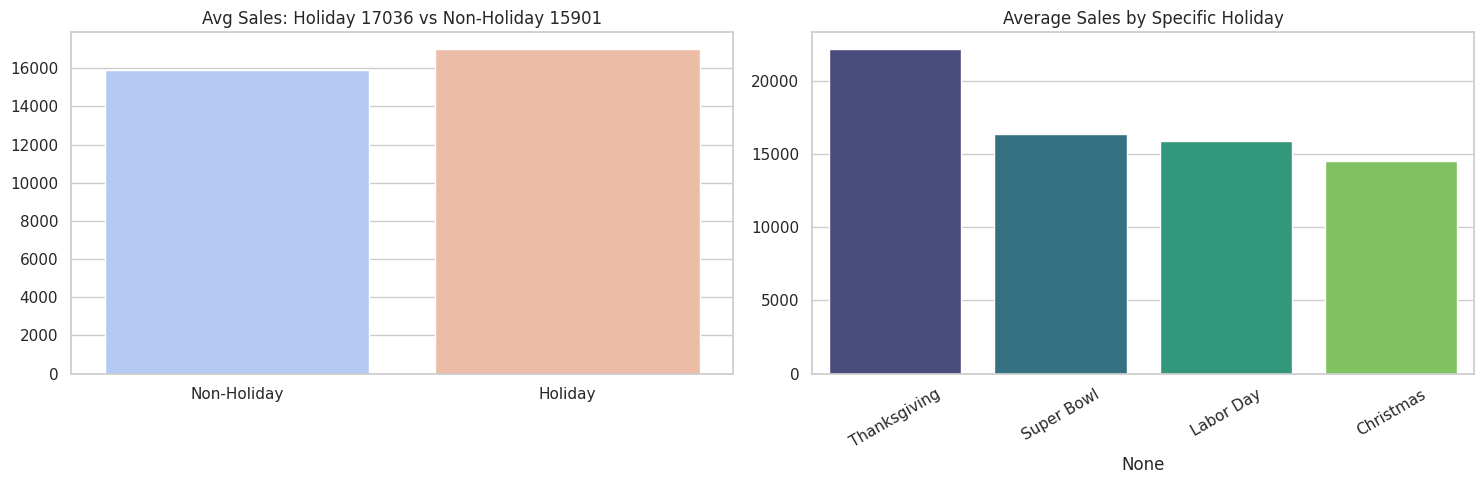

{'Thanksgiving': 22221.0, 'Super Bowl': 16378.0, 'Labor Day': 15882.0, 'Christmas': 14543.0}


In [8]:
holiday_dates = {
  "Super Bowl": ["2010-02-12","2011-02-11","2012-02-10","2013-02-08"],
  "Labor Day": ["2010-09-10","2011-09-09","2012-09-07","2013-09-06"],
  "Thanksgiving": ["2010-11-26","2011-11-25","2012-11-23","2013-11-29"],
  "Christmas": ["2010-12-31","2011-12-30","2012-12-28","2013-12-27"]}
hs = {h: pd.to_datetime(d) for h,d in holiday_dates.items()}
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
h = df_train.groupby("IsHoliday")["Weekly_Sales"].mean()
sns.barplot(x=["Non-Holiday","Holiday"], y=[h[False],h[True]], ax=ax[0], palette="coolwarm")
ax[0].set_title(f"Avg Sales: Holiday {h[True]:.0f} vs Non-Holiday {h[False]:.0f}")
hsales = {name: df_train[df_train.Date.isin(d)].Weekly_Sales.mean() for name,d in hs.items()}
hsales = pd.Series(hsales).sort_values(ascending=False)
sns.barplot(x=hsales.index, y=hsales.values, ax=ax[1], palette="viridis")
ax[1].set_title("Average Sales by Specific Holiday"); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig("docs/eda_holidays.png", dpi=90); plt.show()
print(hsales.round().to_dict())

In [ ]:
md_cols  = [f"MarkDown{i}" for i in range(1, 6)]
exo_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
MD_START = pd.Timestamp("2011-11-11")

md_era = df_train[df_train.Date >= MD_START]
print(f"markdown era: {md_era.Date.min().date()} -> {md_era.Date.max().date()}"
      f"   {len(md_era):,} rows ({len(md_era)/len(df_train):.1%} of train)")
print("\nresidual NA inside the era (these are genuine 'no promotion' zeros):")
print((md_era[md_cols].isna().mean() * 100).round(1).astype(str).add(" %").to_string())

d_naive = df_train[["Weekly_Sales"] + md_cols].copy()
d_naive[md_cols] = d_naive[md_cols].fillna(0)
d_era = md_era[["Weekly_Sales", "Size"] + exo_cols + md_cols].copy()
d_era[md_cols] = d_era[md_cols].fillna(0)

cmp = pd.DataFrame({
    "naive: fillna(0) over all rows": d_naive.corr()["Weekly_Sales"][md_cols],
    "corrected: markdown era only":   d_era.corr()["Weekly_Sales"][md_cols],
})
cmp["x"] = (cmp.iloc[:, 1] / cmp.iloc[:, 0].abs().clip(lower=1e-9)).round(1)
print("\n(1) MarkDown correlation with Weekly_Sales -- the fabricated zeros suppressed it:")
print(cmp.round(3).to_string())

g = df_train.groupby(["Store", "Dept"])
within = pd.DataFrame({c: df_train[c] - g[c].transform("mean") for c in ["Weekly_Sales"] + exo_cols})

pooled_r = df_train[["Weekly_Sales", "Size"] + exo_cols].corr()["Weekly_Sales"].drop("Weekly_Sales")
within_r = within.corr()["Weekly_Sales"].drop("Weekly_Sales")

side = pd.DataFrame({"pooled (between+within)": pooled_r, "within-series only": within_r})
side.loc["Size", "within-series only"] = np.nan
print("\n(2) Exogenous variables -- pooled correlation vs. within-series correlation:")
print(side.round(3).to_string())
print("   Size: within-series r is UNDEFINED (constant per series). Its pooled r=0.244 is")
print("   pure cross-section -- useful as a static feature, useless as a temporal signal.")

md_era_f = md_era[["Store", "Dept", "Weekly_Sales"] + md_cols].copy()
md_era_f[md_cols] = md_era_f[md_cols].fillna(0)
ge = md_era_f.groupby(["Store", "Dept"])
within_md = pd.DataFrame({c: md_era_f[c] - ge[c].transform("mean")
                          for c in ["Weekly_Sales"] + md_cols})
md_side = pd.DataFrame({
    "era-only, pooled":   d_era.corr()["Weekly_Sales"][md_cols],
    "era-only, within-series": within_md.corr()["Weekly_Sales"][md_cols],
})
print("\n(3) MarkDowns, pooled vs within-series (both restricted to the markdown era):")
print(md_side.round(3).to_string())
print("   If `within` collapses toward 0, the era-only r was mostly 'big stores promote more")
print("   and also sell more' -- a static store effect, not a promotion response.")

fig, ax = plt.subplots(1, 2, figsize=(17, 7))
sns.heatmap(d_era.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, ax=ax[0],
            vmin=-1, vmax=1, cbar=False)
ax[0].set_title("Pooled correlation, markdown era only\n(between + within series)")
sns.heatmap(within.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, ax=ax[1],
            vmin=-1, vmax=1, cbar=False)
ax[1].set_title("Within-series correlation (each series demeaned)\n(what a temporal feature can exploit)")
plt.tight_layout(); plt.savefig("docs/eda_correlation.png", dpi=90); plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

HORIZON = df_test.Date.nunique()

def series(store, dept):
    s = df_train[(df_train.Store == store) & (df_train.Dept == dept)].sort_values("Date")
    return s.set_index("Date")["Weekly_Sales"]

ts = series(1, 1)
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(ts, lags=52, ax=ax[0]);  ax[0].set_title("ACF - Store 1 / Dept 1")
plot_pacf(ts, lags=52, ax=ax[1]); ax[1].set_title("PACF - Store 1 / Dept 1")

for axis in ax:
    axis.axvspan(0.5, HORIZON - 0.5, color="red", alpha=0.07, zorder=0)
    axis.axvline(HORIZON, color="red", ls="--", lw=1)
    axis.text(HORIZON - 1, axis.get_ylim()[1] * 0.92,
              f"lag < {HORIZON}: not available at inference",
              rotation=90, ha="right", va="top", fontsize=8, color="crimson")

plt.tight_layout(); plt.savefig("docs/eda_acf_pacf.png", dpi=90); plt.show()

acf_vals = acf(ts, nlags=52)
print(f"Test horizon: {HORIZON} weeks -> only lags >= {HORIZON} resolve for every test row.\n")
print("ACF at selected lags (Store 1 / Dept 1):")
for lag in (1, 2, 4, 26, 39, 43, 52):
    flag = "usable" if lag >= HORIZON else "NOT usable (inside horizon)"
    print(f"  lag {lag:>3}: {acf_vals[lag]:+.3f}   {flag}")
print("\nNote: the lag-1 spike is largely the series LEVEL (non-stationarity), not exploitable")
print("short-term signal. Section 11 shows the lag-52 spike is genuine week-of-year seasonality.")

In [ ]:
N_WEEKS = df_train.Date.nunique()

pivot   = df_train.groupby(["Date", "Dept"])["Weekly_Sales"].mean().unstack()
r_naive = pivot.corr()

woy_a   = pivot.index.isocalendar().week.values
resid   = pivot.apply(lambda s: s - s.groupby(woy_a).transform("mean"))
r_resid = resid.corr()
print(f"week-of-year means are estimated from only {N_WEEKS/52:.1f} observations per week --")
print("so stage 1 removes seasonality aggressively. That is the intent: what is left over?\n")

cnt        = df_train.groupby(["Store", "Dept"]).size()
full_pairs = cnt[cnt == N_WEEKS].index
key        = pd.MultiIndex.from_arrays([df_train.Store, df_train.Dept])
sub_all    = df_train[key.isin(full_pairs)]

mats = []
for st, sub in sub_all.groupby("Store"):
    p = sub.pivot_table(index="Date", columns="Dept", values="Weekly_Sales")
    if p.shape[1] < 5:
        continue
    w  = p.index.isocalendar().week.values
    rr = p.apply(lambda s: s - s.groupby(w).transform("mean"))
    mats.append(rr.corr())
r_within = pd.concat(mats).groupby(level=0).mean()
print(f"stage 2 averaged {len(mats)} per-store correlation matrices "
      f"(stores with >=5 full-history depts)\n")

def offdiag_mean_abs(m):
    v = m.where(~np.eye(len(m), dtype=bool)).stack()
    return v.abs().mean()

print("mean |r| over all department pairs, as each confound is removed:")
print(f"  stage 0  store-averaged, raw                : {offdiag_mean_abs(r_naive):.3f}")
print(f"  stage 1  store-averaged, week-of-year removed: {offdiag_mean_abs(r_resid):.3f}")
print(f"  stage 2  per-store, week-of-year removed     : {offdiag_mean_abs(r_within):.3f}")

stacked = r_naive.stack()
stacked = stacked[stacked.index.get_level_values(0) < stacked.index.get_level_values(1)]
top = stacked.sort_values(ascending=False).head(10)

rows = []
for (a, b), r0 in top.items():
    rows.append({
        "Dept A": a, "Dept B": b,
        "stage 0 (naive)": r0,
        "stage 1 (woy removed)": r_resid.loc[a, b] if a in r_resid.index and b in r_resid.columns else np.nan,
        "stage 2 (per-store)":   r_within.loc[a, b] if a in r_within.index and b in r_within.columns else np.nan,
    })
print("\nThe naive top-10 pairs, re-measured under each control:")
print(pd.DataFrame(rows).round(3).to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(21, 6))
for a, (m, t) in zip(ax, [(r_naive, "stage 0: store-averaged, raw"),
                          (r_resid, "stage 1: week-of-year removed"),
                          (r_within, "stage 2: per-store, woy removed")]):
    sns.heatmap(m, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=a, cbar=False)
    a.set_title(t)
plt.tight_layout(); plt.savefig("docs/eda_dept_corr.png", dpi=90); plt.show()

Negative sales: 1285 (0.30%) - returns


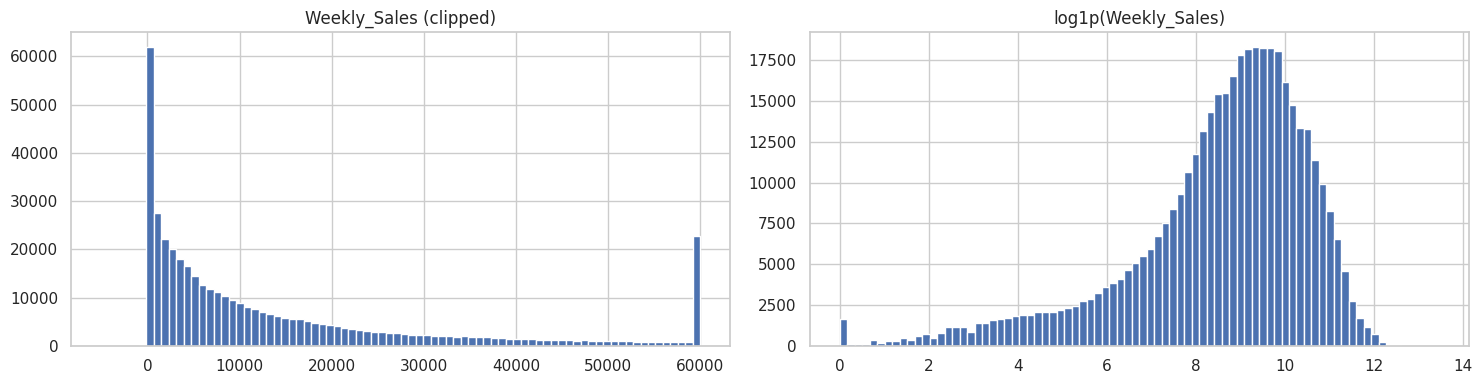

In [12]:
neg = int((df_train.Weekly_Sales<0).sum())
print(f"Negative sales: {neg} ({neg/len(df_train)*100:.2f}%) - returns")
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].hist(df_train.Weekly_Sales.clip(-5000, 60000), bins=80); ax[0].set_title("Weekly_Sales (clipped)")
ax[1].hist(np.log1p(df_train.Weekly_Sales.clip(lower=0)), bins=80); ax[1].set_title("log1p(Weekly_Sales)")
plt.tight_layout(); plt.savefig("docs/eda_target_dist.png", dpi=90); plt.show()

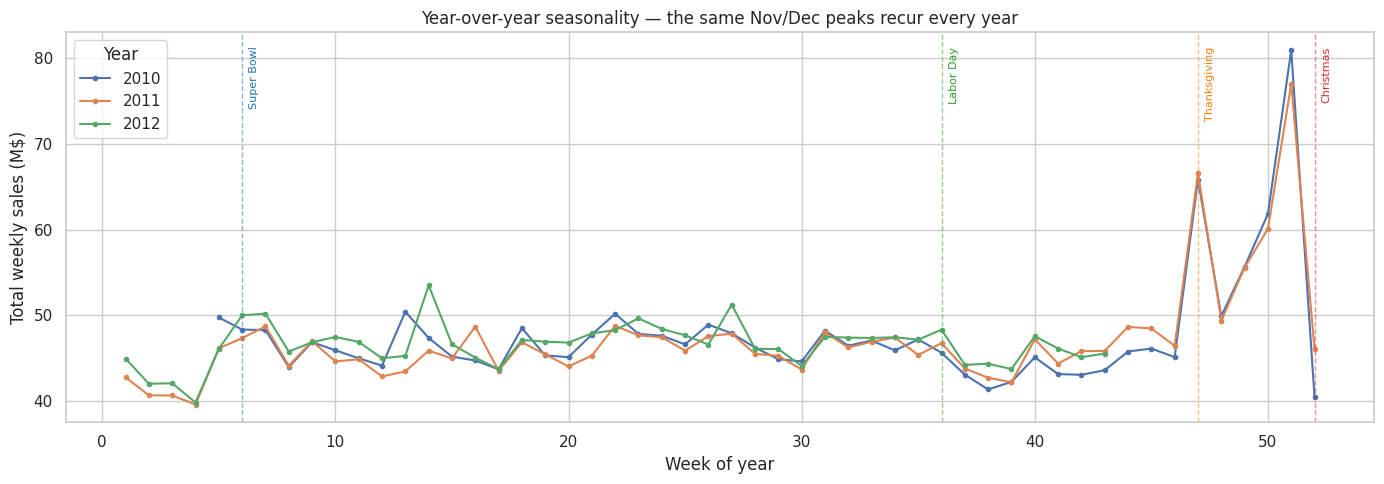

In [13]:
HOLIDAY_BY_MONTH = {2: "Super Bowl", 9: "Labor Day", 11: "Thanksgiving", 12: "Christmas"}
HOLIDAY_COLOR    = {"Super Bowl": "tab:blue", "Labor Day": "tab:green",
                    "Thanksgiving": "tab:orange", "Christmas": "tab:red"}
hol = df_train.loc[df_train["IsHoliday"], "Date"].drop_duplicates().to_frame()
hol["name"] = hol["Date"].dt.month.map(HOLIDAY_BY_MONTH).fillna("Holiday")
hol_woy = (hol.assign(Week=hol["Date"].dt.isocalendar().week.astype(int))
              .groupby("name")["Week"].median())

wk = df_train.copy()
wk["Year"] = wk.Date.dt.year
wk["Week"] = wk.Date.dt.isocalendar().week.astype(int)
yoy = wk.groupby(["Year","Week"])["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(14,5))
for yr, g in yoy.groupby("Year"):
    plt.plot(g.Week, g.Weekly_Sales/1e6, marker=".", label=str(yr))

for name, w in hol_woy.items():
    plt.axvline(w, color=HOLIDAY_COLOR.get(name, "grey"), linestyle="--", alpha=0.5, linewidth=1)
    plt.text(w+0.3, plt.ylim()[1]*0.98, name, rotation=90, va="top", fontsize=8,
             color=HOLIDAY_COLOR.get(name, "grey"))

plt.xlabel("Week of year"); plt.ylabel("Total weekly sales (M$)")
plt.title("Year-over-year seasonality — the same Nov/Dec peaks recur every year")
plt.legend(title="Year"); plt.tight_layout()
plt.savefig("docs/eda_yoy_overlay.png", dpi=90); plt.show()

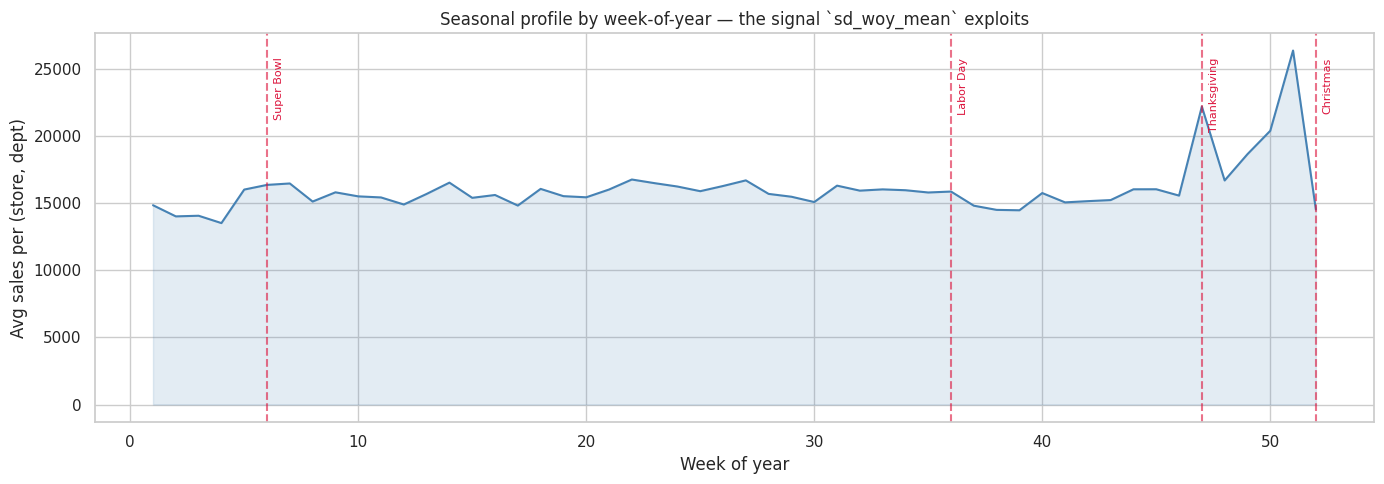

In [14]:
woy = wk.groupby("Week")["Weekly_Sales"].mean()
plt.figure(figsize=(14,5))
plt.plot(woy.index, woy.values, color="steelblue")
plt.fill_between(woy.index, woy.values, alpha=0.15, color="steelblue")
for name, dts in hs.items():
    w = int(np.median(dts.isocalendar().week.values))
    plt.axvline(w, color="crimson", ls="--", alpha=0.6)
    plt.text(w+0.3, woy.max()*0.98, name, rotation=90, va="top", fontsize=8, color="crimson")
plt.xlabel("Week of year"); plt.ylabel("Avg sales per (store, dept)")
plt.title("Seasonal profile by week-of-year — the signal `sd_woy_mean` exploits")
plt.tight_layout(); plt.savefig("docs/eda_woy_profile.png", dpi=90); plt.show()

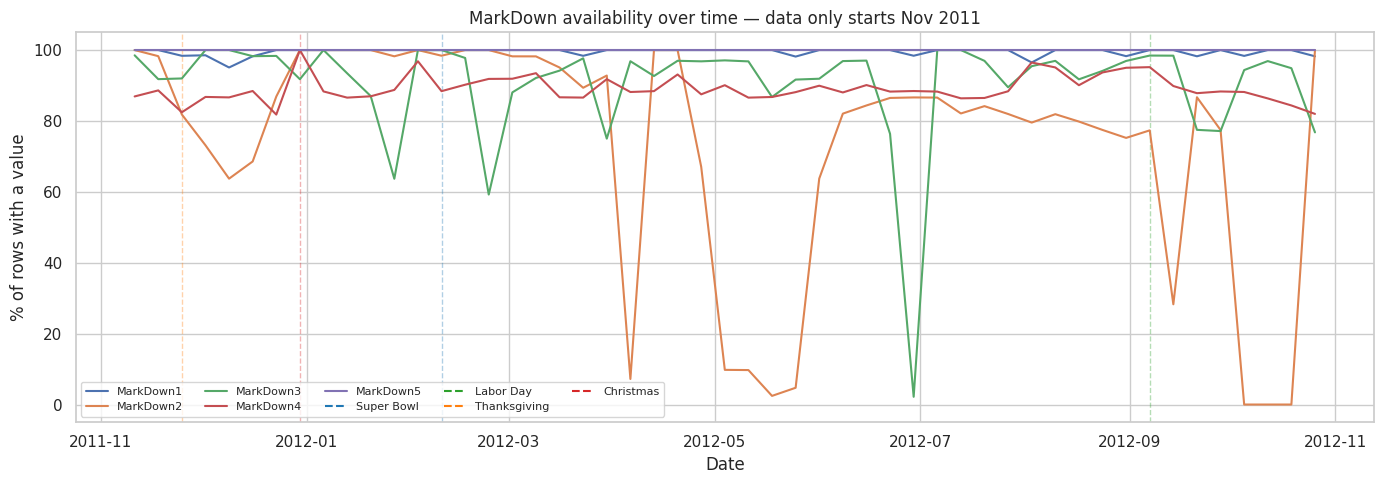

Overall MarkDown missing %: {'MarkDown1': 64.3, 'MarkDown2': 73.6, 'MarkDown3': 67.5, 'MarkDown4': 68.0, 'MarkDown5': 64.1}
MarkDown data first appears: 2011-11-11


In [15]:
from matplotlib.lines import Line2D
HOLIDAY_BY_MONTH = {2: "Super Bowl", 9: "Labor Day", 11: "Thanksgiving", 12: "Christmas"}
HOLIDAY_COLOR    = {"Super Bowl": "tab:blue", "Labor Day": "tab:green",
                    "Thanksgiving": "tab:orange", "Christmas": "tab:red"}
hol = df_train.loc[df_train["IsHoliday"], "Date"].drop_duplicates().to_frame()
hol["name"] = hol["Date"].dt.month.map(HOLIDAY_BY_MONTH).fillna("Holiday")

md_cols = [f"MarkDown{i}" for i in range(1,6)]
avail = df_train.groupby("Date")[md_cols].apply(lambda g: g.notna().mean())

first = avail.index[(avail.sum(axis=1) > 0).values].min()
avail = avail.loc[first:]

plt.figure(figsize=(14,5))
for c in md_cols:
    plt.plot(avail.index, avail[c]*100, label=c)

for _, r in hol[hol["Date"] >= first].iterrows():
    plt.axvline(r["Date"], color=HOLIDAY_COLOR.get(r["name"], "grey"),
                linestyle="--", alpha=0.35, linewidth=1, zorder=1)
hol_handles = [Line2D([0],[0], color=c, linestyle="--", label=n)
               for n, c in HOLIDAY_COLOR.items() if n in set(hol[hol["Date"] >= first]["name"])]

plt.ylabel("% of rows with a value"); plt.xlabel("Date")
plt.title(f"MarkDown availability over time — data only starts {pd.Timestamp(first):%b %Y}")
md_handles, md_labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=md_handles + hol_handles, ncol=5, fontsize=8); plt.tight_layout()
plt.savefig("docs/eda_markdown_availability.png", dpi=90); plt.show()
print("Overall MarkDown missing %:", (df_train[md_cols].isna().mean()*100).round(1).to_dict())
print("MarkDown data first appears:", pd.Timestamp(first).date())

In [ ]:
def pre_xmas_days(week_end):
    days = pd.date_range(week_end - pd.Timedelta(days=6), week_end)
    lo = pd.Timestamp(week_end.year, 12, 18)
    hi = pd.Timestamp(week_end.year, 12, 24)
    return int(((days >= lo) & (days <= hi)).sum())

def days_to_christmas(week_end):
    return (week_end - pd.Timestamp(week_end.year, 12, 25)).days

cal = (pd.concat([df_train[["Date", "IsHoliday"]].assign(split="train"),
                  df_test[["Date", "IsHoliday"]].assign(split="test")])
         .drop_duplicates("Date").sort_values("Date").reset_index(drop=True))

xmas = cal[cal.IsHoliday & (cal.Date.dt.month == 12)].copy()
xmas["week_start"]      = xmas.Date - pd.Timedelta(days=6)
xmas["dec25_weekday"]   = xmas.Date.dt.year.map(lambda y: pd.Timestamp(y, 12, 25).day_name())
xmas["pre_xmas_days"]   = xmas.Date.map(pre_xmas_days)
xmas["days_after_xmas"] = xmas.Date.map(days_to_christmas)

print("The week flagged IsHoliday=True in December (weight 5), by year:")
print(xmas[["split", "week_start", "Date", "dec25_weekday", "pre_xmas_days", "days_after_xmas"]]
        .rename(columns={"Date": "week_end"}).to_string(index=False))

weekly_tot = df_train.groupby("Date")["Weekly_Sales"].sum()
fig, ax = plt.subplots(figsize=(14, 5))

for yr, colour in [(2010, "tab:blue"), (2011, "tab:orange")]:
    xm = pd.Timestamp(yr, 12, 25)
    sub = weekly_tot[(weekly_tot.index >= xm - pd.Timedelta(days=45)) &
                     (weekly_tot.index <= xm + pd.Timedelta(days=10))]
    offs = [(d - xm).days for d in sub.index]
    ax.plot(offs, sub.values / 1e6, marker="o", color=colour, label=f"{yr} actual sales")
    flag = xmas[xmas.Date.dt.year == yr].Date.iloc[0]
    ax.scatter([(flag - xm).days], [weekly_tot.loc[flag] / 1e6],
               s=260, marker="*", color=colour, edgecolor="black", zorder=5)

flag12 = xmas[xmas.Date.dt.year == 2012].Date.iloc[0]
off12 = (flag12 - pd.Timestamp(2012, 12, 25)).days
ax.axvline(off12, color="crimson", lw=2, ls="-", alpha=0.8)
ax.text(off12 - 0.4, ax.get_ylim()[1] * 0.55,
        f"2012 TEST flagged week ends here ({flag12:%b %d})\n3 pre-Christmas shopping days inside",
        rotation=90, ha="right", va="center", fontsize=9, color="crimson", fontweight="bold")

ax.axvline(0, color="grey", ls="--", lw=1)
ax.text(0.3, ax.get_ylim()[1] * 0.97, "Dec 25", rotation=90, va="top", fontsize=8, color="grey")
ax.set_xlabel("Days from Christmas to the week's end date  (negative = week ends before Dec 25)")
ax.set_ylabel("Total weekly sales (M$)")
ax.set_title("The 5x-weighted Christmas week drifts toward the peak: +6d (2010) -> +5d (2011) -> +3d (2012 test)\n"
             "★ = the week flagged IsHoliday=True")
ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig("docs/eda_christmas_shift.png", dpi=90); plt.show()

print("\nSales in the flagged Christmas week vs the unflagged peak week before it:")
for yr in (2010, 2011):
    flag = xmas[xmas.Date.dt.year == yr].Date.iloc[0]
    peak = weekly_tot[(weekly_tot.index.year == yr) & (weekly_tot.index.month == 12)].idxmax()
    print(f"  {yr}: flagged {flag:%Y-%m-%d} = {weekly_tot[flag]/1e6:5.2f}M (weight 5)   "
          f"| peak {peak:%Y-%m-%d} = {weekly_tot[peak]/1e6:5.2f}M (weight 1)")
print("\n=> Training teaches: 'the weight-5 Christmas week is a TROUGH'.")
print("=> In the 2012 test year that week contains 3 pre-Christmas shopping days.")
print("=> A model that trusts IsHoliday alone will UNDER-predict the highest-weight week in test.")

cal["days_to_christmas"] = cal.Date.map(days_to_christmas)
print("\ndays_to_christmas is computable from the Date alone -> available at inference:")
print(cal[cal.Date.dt.month == 12].groupby(cal.Date.dt.year)["days_to_christmas"]
         .apply(list).to_string())

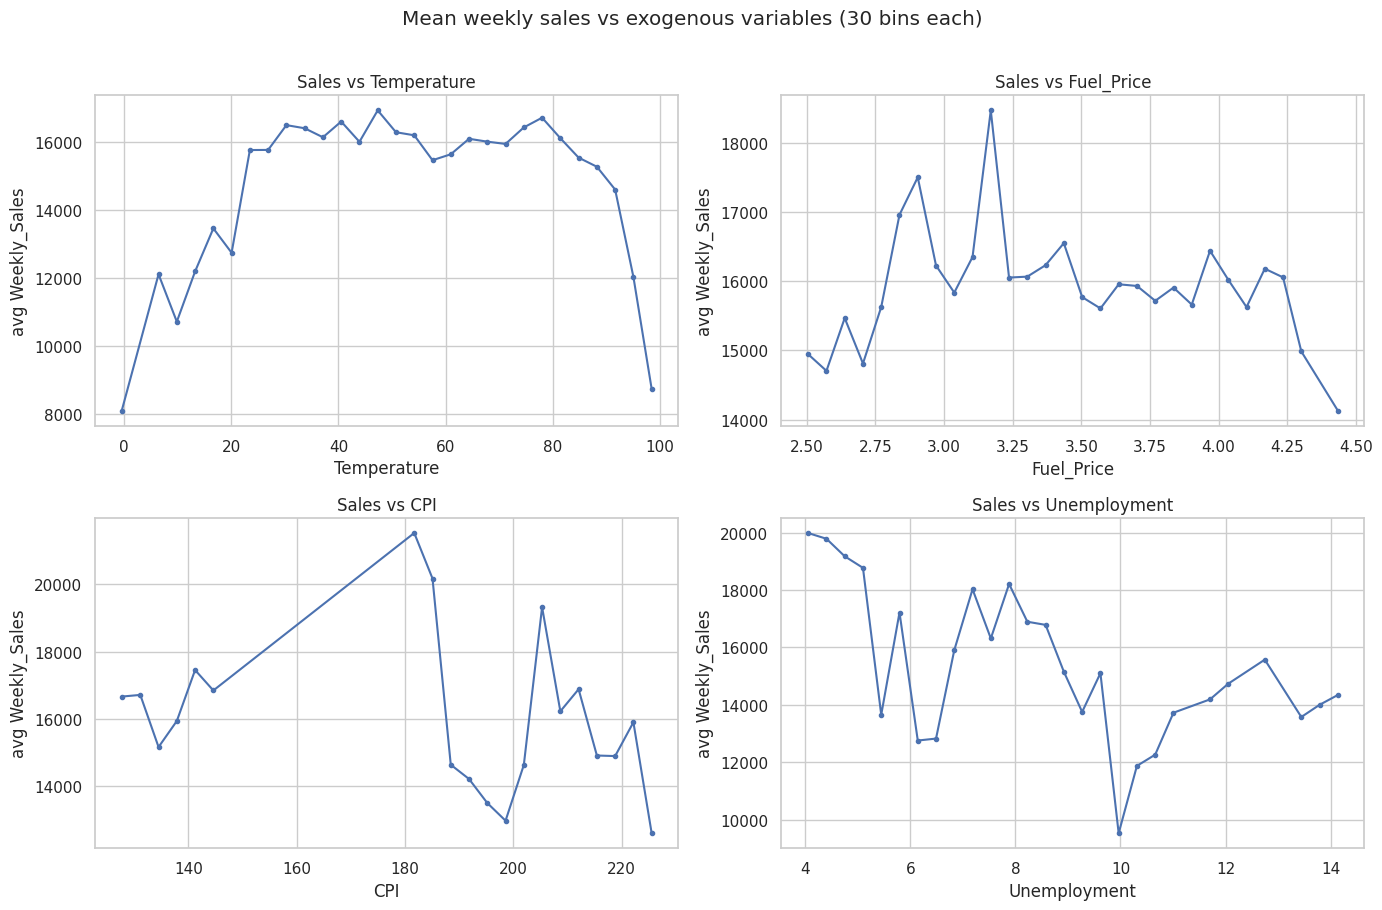

In [16]:
exo = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
for a, col in zip(ax.ravel(), exo):
    piv = df_train.groupby(pd.cut(df_train[col], bins=30), observed=True)["Weekly_Sales"].mean()
    centers = [iv.mid for iv in piv.index]
    a.plot(centers, piv.values, marker=".")
    a.set_xlabel(col); a.set_ylabel("avg Weekly_Sales"); a.set_title(f"Sales vs {col}")
fig.suptitle("Mean weekly sales vs exogenous variables (30 bins each)", y=1.01)
plt.tight_layout(); plt.savefig("docs/eda_exog_relationships.png", dpi=90); plt.show()

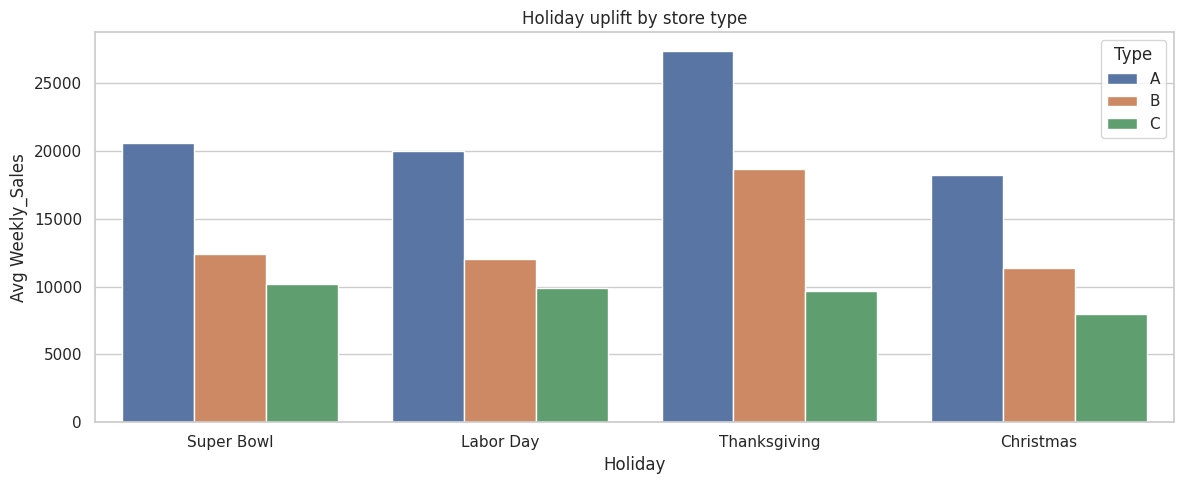

Type                A        B        C
Holiday                                
Christmas     18231.0  11394.0   7963.0
Labor Day     19973.0  12013.0   9871.0
Super Bowl    20604.0  12402.0  10156.0
Thanksgiving  27371.0  18661.0   9680.0


In [17]:
rows = []
for name, dts in hs.items():
    sub = df_train[df_train.Date.isin(dts)]
    for t, v in sub.groupby("Type")["Weekly_Sales"].mean().items():
        rows.append({"Holiday": name, "Type": t, "AvgSales": v})
hd = pd.DataFrame(rows)
plt.figure(figsize=(12, 5))
sns.barplot(data=hd, x="Holiday", y="AvgSales", hue="Type")
plt.title("Holiday uplift by store type"); plt.ylabel("Avg Weekly_Sales")
plt.tight_layout(); plt.savefig("docs/eda_holiday_by_type.png", dpi=90); plt.show()
print(hd.pivot(index="Holiday", columns="Type", values="AvgSales").round(0).to_string())

In [ ]:
print("Missing % per column — train vs test:")
miss_cmp = pd.DataFrame({
    "train_pct": (df_train.isna().mean() * 100).round(2),
    "test_pct":  (df_test.isna().mean() * 100).round(2),
}).fillna(0)
print(miss_cmp[(miss_cmp["train_pct"] > 0) | (miss_cmp["test_pct"] > 0)]
      .sort_values("test_pct", ascending=False).to_string())

for col in ("CPI", "Unemployment"):
    gone = df_test[df_test[col].isna()]
    if len(gone):
        print(f"\n{col}: {len(gone)} missing test rows "
              f"({gone.Date.nunique()} distinct weeks x {gone.Store.nunique()} stores)")
        print(f"  first missing week: {gone.Date.min():%Y-%m-%d}   last: {gone.Date.max():%Y-%m-%d}")
        print(f"  test spans {df_test.Date.min():%Y-%m-%d} .. {df_test.Date.max():%Y-%m-%d}")
        print(f"  -> missing for the FINAL {gone.Date.nunique()} of {df_test.Date.nunique()} test weeks")

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
for a, col in zip(ax, ("CPI", "Unemployment")):
    tr_av = df_train.groupby("Date")[col].apply(lambda s: s.notna().mean() * 100)
    te_av = df_test.groupby("Date")[col].apply(lambda s: s.notna().mean() * 100)
    a.plot(tr_av.index, tr_av.values, color="tab:blue", label="train")
    a.plot(te_av.index, te_av.values, color="tab:red", label="test")
    a.axvline(df_test.Date.min(), color="grey", ls="--", lw=1)
    a.text(df_test.Date.min(), 50, " test starts", fontsize=8, color="grey")
    a.set_ylim(-5, 105); a.set_ylabel("% of rows with a value")
    a.set_title(f"{col} availability"); a.legend(loc="lower left")
fig.suptitle("Exogenous covariates stop being reported partway through the test period", y=1.02)
plt.tight_layout(); plt.savefig("docs/eda_test_missingness.png", dpi=90); plt.show()

md_cols = [f"MarkDown{i}" for i in range(1, 6)]
print("\nMarkDown missing % — train vs test:")
print(pd.DataFrame({"train_pct": (df_train[md_cols].isna().mean() * 100).round(1),
                    "test_pct":  (df_test[md_cols].isna().mean() * 100).round(1)}).to_string())
print("\n=> MarkDowns are ~65-74% missing in TRAIN (not recorded before 2011-11-11)")
print("   but almost fully present in TEST. The train/test missingness is INVERTED.")

In [ ]:
N_WEEKS = df_train.Date.nunique()
HORIZON = df_test.Date.nunique()

train_keys = set(map(tuple, df_train[["Store", "Dept"]].drop_duplicates().values))
test_keys  = set(map(tuple, df_test[["Store", "Dept"]].drop_duplicates().values))
unseen     = test_keys - train_keys
dropped    = train_keys - test_keys

print(f"series in train: {len(train_keys)}   pairs needed in test: {len(test_keys)}")
print(f"  in test but NEVER in train (cold start): {len(unseen)}")
print(f"  in train but not needed in test:         {len(dropped)}")
if unseen:
    print(f"  cold-start pairs: {sorted(unseen)}")

hist_len = df_train.groupby(["Store", "Dept"]).size()
short_52 = (hist_len < 52).sum()
short_10 = (hist_len < 10).sum()
full     = (hist_len == N_WEEKS).sum()

nonpos = df_train.assign(np_=df_train.Weekly_Sales <= 0).groupby(["Store", "Dept"])["np_"].mean()

print(f"\nhistory length (out of {N_WEEKS} weeks):")
print(f"  full history:   {full:5d}  ({full/len(hist_len):.1%})")
print(f"  < 52 weeks:     {short_52:5d}  -> short history (proxy; see direct check below)")
print(f"  < 10 weeks:     {short_10:5d}  -> essentially no usable history")
print(f"  >20% non-positive weeks: {(nonpos > 0.2).sum():5d}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(hist_len.values, bins=40, color="steelblue")
ax[0].axvline(52, color="crimson", ls="--", label="52 wks (row-count proxy - see below, it MISSES 862 rows)")
ax[0].set_title("Weeks of history per series"); ax[0].set_xlabel("weeks"); ax[0].legend(fontsize=8)
ax[0].set_yscale("log"); ax[0].set_ylabel("series (log scale)")

ax[1].hist(nonpos.values * 100, bins=40, color="indianred")
ax[1].set_title("% of weeks with sales <= 0"); ax[1].set_xlabel("% non-positive weeks")
ax[1].set_yscale("log")

stats = df_train.groupby(["Store", "Dept"])["Weekly_Sales"].agg(["mean", "std"])
cv = (stats["std"] / stats["mean"].abs()).replace([np.inf, -np.inf], np.nan).dropna()
ax[2].hist(cv.clip(0, 3).values, bins=40, color="seagreen")
ax[2].set_title("Coefficient of variation (clipped at 3)"); ax[2].set_xlabel("std / |mean|")
ax[2].set_yscale("log")
plt.tight_layout(); plt.savefig("docs/eda_cold_start.png", dpi=90); plt.show()

test_lens = df_test.merge(hist_len.rename("hist_wk").reset_index(), on=["Store", "Dept"], how="left")
test_lens["hist_wk"] = test_lens["hist_wk"].fillna(0).astype(int)

observed = set(zip(df_train.Store, df_train.Dept, df_train.Date))
lag_date = test_lens.Date - pd.Timedelta(days=364)
test_lens["lag52_ok"] = [
    k in observed for k in zip(test_lens.Store, test_lens.Dept, lag_date)
]

print(f"\nlag-52 source window: {lag_date.min().date()} -> {lag_date.max().date()}"
      f"  (entirely inside train: {df_train.Date.min().date()} -> {df_train.Date.max().date()})")

n_test     = len(test_lens)
aff_unseen = int((test_lens["hist_wk"] == 0).sum())
aff_nolag  = int((~test_lens["lag52_ok"]).sum())
aff_warm   = aff_nolag - aff_unseen

print(f"\nTEST rows needing a fallback (measured, not inferred from row count):")
print(f"  lag_52 resolves:                {n_test - aff_nolag:6d}  ({(n_test-aff_nolag)/n_test:.3%} of test)")
print(f"  lag_52 UNDEFINED:               {aff_nolag:6d}  ({aff_nolag/n_test:.3%} of test)")
print(f"    of which cold start (no history at all): {aff_unseen:6d}")
print(f"    of which has history but not at D-364d:  {aff_warm:6d}")

proxy_flags   = test_lens["hist_wk"] < 52
missed        = int((~proxy_flags & ~test_lens["lag52_ok"]).sum())
false_alarm   = int(( proxy_flags &  test_lens["lag52_ok"]).sum())
print(f"\nrow-count proxy (`hist_wk < 52`) vs. direct coverage:")
print(f"  rows it would MISS  (no lag_52, but >=52 wks of history): {missed:6d}")
print(f"  rows it FALSE-ALARMS (<52 wks of history, lag_52 present): {false_alarm:6d}")
if missed == 0 and false_alarm == 0:
    print("  -> the two agree here: every series' history is contiguous, so row count happened")
    print("     to be a faithful proxy. It is not one in general -- keep the direct check.")

bad = test_lens[~test_lens["lag52_ok"]]
print(f"\nundefined-lag rows span {bad.groupby(['Store','Dept']).ngroups} (Store,Dept) series"
      f"; {int(bad.IsHoliday.sum())} of them fall on 5x-weighted holiday weeks")

print(f"\n=> Small in row count, but a global model emits a prediction for every one of them.")
print(f"   Kaggle scores all {n_test} rows; there is no 'skip' option.")
print(f"   Fallback ladder (see README S18): lag_52 -> sd_woy_mean -> (Store,Dept) mean")
print(f"   -> (Dept,Type) mean -> global mean. Each rung drops one conditioning variable.")
print(f"   NOTE: 2,005 of the 2,041 rows HAVE history -- only 36 are true cold start, so the")
print(f"   first fallback rung (sd_woy_mean) carries almost all of them, not the (Dept,Type) rung.")

In [ ]:
def wmae(y_true, y_pred, is_holiday):
    w = np.where(np.asarray(is_holiday, dtype=bool), 5.0, 1.0)
    return float(np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w))

assert abs(wmae([10, 20], [8, 15], [True, False]) - 15 / 6) < 1e-9
print("wmae() passes its hand-computed unit test.\n")

h = df_test.IsHoliday.sum(); n = len(df_test)
print(f"TEST: {h:,} holiday rows / {n:,} = {h/n:.2%} of rows")
print(f"      weight share = 5*{h:,} / (5*{h:,} + {n-h:,}) = {5*h/(5*h + (n-h)):.2%} of the metric")
print(f"      -> roughly ONE THIRD of the score is decided by 3 of 39 weeks.")
print(f"      holiday weeks in test: {sorted(df_test.loc[df_test.IsHoliday, 'Date'].dt.strftime('%Y-%m-%d').unique())}\n")

HORIZON = df_test.Date.nunique()

def describe_fold(name, val_start, val_end):
    tr = df_train[df_train.Date < val_start]
    va = df_train[(df_train.Date >= val_start) & (df_train.Date <= val_end)]
    hol_weeks = sorted(va.loc[va.IsHoliday, "Date"].dt.strftime("%Y-%m-%d").unique())
    hw = va.IsHoliday.sum(); share = 5 * hw / (5 * hw + (len(va) - hw))
    return {"fold": name, "train_wks": tr.Date.nunique(), "val_wks": va.Date.nunique(),
            "hol_weeks": len(hol_weeks), "hol_weight_share": f"{share:.2%}",
            "which": ", ".join(w[5:] for w in hol_weeks)}

folds = pd.DataFrame([
    describe_fold("A: last 39 weeks (naive)",     pd.Timestamp("2012-02-03"), pd.Timestamp("2012-10-26")),
    describe_fold("B: calendar-aligned (chosen)", pd.Timestamp("2011-11-04"), pd.Timestamp("2012-07-27")),
    describe_fold("C: calendar-aligned, -1 year", pd.Timestamp("2010-11-05"), pd.Timestamp("2011-07-29")),
])
print("Candidate validation folds (each 39 weeks, matching the test horizon):")
print(folds.to_string(index=False))
print(f"\nTEST for comparison: 39 wks, 3 holiday weeks, weight share 29.61%")
print("=> Fold A contains NO Thanksgiving and NO Christmas. It cannot measure the thing")
print("   that decides ~30% of the score. Fold B reproduces the test's holiday composition.")
print("=> Fold C has only 39 weeks of training history -> lag_52 is undefined. Unusable as a model fold.\n")

def fit_predict_baselines(val_start, val_end):
    tr = df_train[df_train.Date < val_start].copy()
    va = df_train[(df_train.Date >= val_start) & (df_train.Date <= val_end)].copy()

    gmean = tr.Weekly_Sales.mean()
    sd_mean = tr.groupby(["Store", "Dept"])["Weekly_Sales"].mean().rename("sd_mean")
    tr["woy"] = tr.Date.dt.isocalendar().week.astype(int)
    va["woy"] = va.Date.dt.isocalendar().week.astype(int)
    woy_med = tr.groupby(["Store", "Dept", "woy"])["Weekly_Sales"].median().rename("woy_med")

    lag = tr[["Store", "Dept", "Date", "Weekly_Sales"]].rename(
        columns={"Date": "lag_date", "Weekly_Sales": "snaive"})
    va["lag_date"] = va.Date - pd.Timedelta(weeks=52)
    va = (va.merge(lag, on=["Store", "Dept", "lag_date"], how="left")
            .merge(sd_mean, on=["Store", "Dept"], how="left")
            .merge(woy_med, on=["Store", "Dept", "woy"], how="left"))

    fallback = va.sd_mean.fillna(gmean)
    preds = {
        "global mean":                          pd.Series(gmean, index=va.index),
        "per-(store,dept) mean":                fallback,
        "median by (store,dept,week-of-year)":  va.woy_med.fillna(fallback),
        "seasonal naive (lag-52)":              va.snaive.fillna(fallback),
    }
    return va, {k: wmae(va.Weekly_Sales, p, va.IsHoliday) for k, p in preds.items()}

rows = []
for label, (s, e) in {"A (naive)":      (pd.Timestamp("2012-02-03"), pd.Timestamp("2012-10-26")),
                      "B (aligned)":    (pd.Timestamp("2011-11-04"), pd.Timestamp("2012-07-27"))}.items():
    va, scores = fit_predict_baselines(s, e)
    for k, v in scores.items():
        rows.append({"baseline": k, "fold": label, "WMAE": round(v, 1)})

base = pd.DataFrame(rows).pivot(index="baseline", columns="fold", values="WMAE")
base["optimism of fold A"] = (base["B (aligned)"] - base["A (naive)"]).round(1)
print("Baseline WMAE (lower is better):")
print(base.sort_values("B (aligned)", ascending=False).to_string())

va, _ = fit_predict_baselines(pd.Timestamp("2011-11-04"), pd.Timestamp("2012-07-27"))
pred = va.snaive.fillna(va.sd_mean.fillna(df_train.Weekly_Sales.mean()))
err = np.where(va.IsHoliday, 5.0, 1.0) * np.abs(va.Weekly_Sales - pred)
hol_share = err[va.IsHoliday.values].sum() / err.sum()
print(f"\nSeasonal-naive error on fold B: {hol_share:.1%} of total weighted error comes from")
print(f"holiday weeks, which are only {va.IsHoliday.mean():.2%} of rows.")